## Examples: Binary classification metrics

#### In this notebook, we'll look at how to assess the performance of a logistic regression model using various binary classification metrics such as accuracy, precision, recall, and the F1 score.

### **Learning Objectives**:
#### By the end of this notebook, you should be able to:
#### - Understand how to use and interpret the confusion matrix and the classification report to assess the performance of a binary classifier.
#### - Understand the metrics accuracy, precision, recall, and F1 score.
#### - Know how to implement the various binary classification metrics in Python.

### **Building a logistic regression model**

#### **1.1 The Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
# import dataset
from sklearn.datasets import load_breast_cancer

# suppress cell warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
X, y = load_breast_cancer(return_X_y=True)

In [7]:
X = pd.DataFrame(X)
y = pd.DataFrame(y, columns=['Target'])

In [8]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **1.2 Training the model**

In [9]:
# SPlit into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

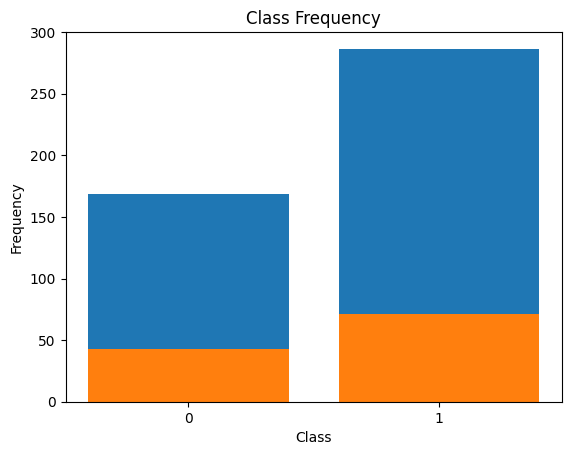

1    357
0    212
Name: Target, dtype: int64

In [24]:
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
unique, counts = np.unique(y_test, return_counts=True)
plt.bar(unique, counts)

plt.title('Class Frequency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(ticks=[0,1], labels=[0,1])
plt.ylim(top=300)

plt.show()
y['Target'].value_counts()

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
# create logistic regression model instance
lm = LogisticRegression()

In [27]:
# Train the Logistic regression model
lm.fit(X_train, y_train)

LogisticRegression()

In [28]:
# Get the model intercept
lm.intercept_[0]

0.3091637082550099

In [29]:
# Get the model coefficients
coeff_df = pd.DataFrame(lm.coef_.T, X.columns, columns=['Coefficient'])
coeff_df.head()

,Coefficient
0,1.602746
1,0.334788
2,0.073041
3,-0.008145
4,-0.062345


In [38]:
# Get predictions
pred_lm = lm.predict(X_test)

### **2. Assessing model performance using the confusion matrix.**

In [39]:
from sklearn.metrics import confusion_matrix

In [40]:
confusion_matrix(y_test, pred_lm)

array([[40,  3],
       [ 1, 70]], dtype=int64)

In [41]:
labels = ['0: Malignant', '1: Benign']

pd.DataFrame(
    data=confusion_matrix(y_test, pred_lm),
    index=labels,
    columns=labels
)

,0: Malignant,1: Benign
0: Malignant,40,3
1: Benign,1,70


In [42]:
from sklearn.metrics import classification_report

In [43]:
print('Classification Report')
print(classification_report(y_test, pred_lm, target_names=['0: Malignant', '1: Benign']))

Classification Report
              precision    recall  f1-score   support

0: Malignant       0.98      0.93      0.95        43
   1: Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

